# B.6 — SpatialPeeler benchmark evaluation: 3×3×3 parameter grid

Runs SpatialPeeler on all 27 benchmark conditions generated by `B.5.benchmark_nmfGenes_grid.ipynb`.

**Conditions:** 3 perturb_fracs × 3 lambdas × 3 top_genes = 27 case files in `generated_benchmark_data_final/`.

**Metric:** spot-based in-circle AUROC — for each condition, the top factor chosen by  
SpatialPeeler (highest positive logistic regression coefficient) is evaluated against  
the ground-truth `obs['in_circle']` column on case beads only.

In [6]:
import sys
import warnings
from itertools import product
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import statsmodels.api as sm
from sklearn.decomposition import NMF
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import roc_auc_score

warnings.simplefilter('ignore', category=ConvergenceWarning)
sc.settings.verbosity = 0

ROOT    = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler')
sys.path.insert(0, str(ROOT))

RAND_SEED  = 28
N_FACTORS  = 15
np.random.seed(RAND_SEED)

DATA_DIR  = ROOT / 'benchmark' / 'generated_benchmark_data'
FINAL_DIR = ROOT / 'benchmark' / 'generated_benchmark_data_final'


In [ ]:

print('ROOT:', ROOT)
print('Case files:', len(list(FINAL_DIR.glob('*.h5ad'))))

## 1. Load control (shared across all conditions)

In [2]:
adata_ctrl = ad.read_h5ad(DATA_DIR / 'adata06_top.h5ad')
adata_ctrl.obs['sample_id'] = 'ctrl'
adata_ctrl.obs['status']    = 0
adata_ctrl.obs['Condition'] = 'Control'
if 'in_circle' not in adata_ctrl.obs.columns:
    adata_ctrl.obs['in_circle'] = False
adata_ctrl.obs['in_circle'] = adata_ctrl.obs['in_circle'].astype(bool)

print('Control:', adata_ctrl.shape)

Control: (34392, 26548)


## 2. Define the parameter grid

In [11]:
PERTURB_FRACS  = [0.30, 0.50, 0.70]
FIXED_LAMS     = [0.5,  0.3,  0.15]
TOP_GENES_LIST = [1, 5, 10]

grid = list(product(PERTURB_FRACS, FIXED_LAMS, TOP_GENES_LIST))
print(f'{len(grid)} conditions')

27 conditions


## 3. Helper functions

In [4]:
def preprocess(adata_ctrl, adata_case):
    """Concat, filter, normalise, HVG, scale. Returns combined adata."""
    adata = ad.concat(
        [adata_ctrl, adata_case],
        join='inner', merge='first',
        label='sample_id', keys=['ctrl', 'case'],
        index_unique='-'
    )
    for col in ['status', 'Condition', 'in_circle']:
        adata.obs[col] = np.concatenate([
            adata_ctrl.obs[col].values,
            adata_case.obs[col].values
        ])
    adata.obs['status']    = adata.obs['status'].astype(int)
    adata.obs['in_circle'] = adata.obs['in_circle'].astype(bool)

    adata.layers['counts'] = adata.X.copy()

    # gene filter
    min_cells = max(1, adata.n_obs // 500)
    n_expr    = np.array((adata.X > 0).sum(axis=0)).flatten()
    adata     = adata[:, n_expr >= min_cells].copy()

    # lognorm + HVG
    adata.layers['lognorm'] = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4, layer='lognorm')
    sc.pp.log1p(adata, layer='lognorm')
    sc.pp.highly_variable_genes(
        adata, n_top_genes=2000,
        batch_key='sample_id', flavor='seurat',
        layer='lognorm', subset=False
    )
    adata = adata[:, adata.var['highly_variable']].copy()

    sc.pp.scale(adata, zero_center=False)
    return adata


def run_nmf(adata, n_factors=N_FACTORS, rand_seed=RAND_SEED):
    X = adata.X
    if sp.issparse(X):
        X = X.toarray()
    X = X.astype(np.float32)
    model = NMF(n_components=n_factors, init='nndsvda',
                random_state=rand_seed, max_iter=1000, solver='cd')
    W = model.fit_transform(X)
    adata.obsm['X_nmf'] = W
    return W


def run_spatialpeeler(adata, n_factors=N_FACTORS):
    """Logistic regression for each factor. Returns list of result dicts."""
    X  = adata.obsm['X_nmf']
    y  = adata.obs['status'].values
    results = []
    for i in range(n_factors):
        Xi    = X[:, i].reshape(-1, 1)
        X_int = sm.add_constant(Xi)
        try:
            fit = sm.Logit(y, X_int).fit(disp=False)
            p_hat = fit.predict(X_int)
            coef  = float(fit.params[1])
            pval  = float(fit.pvalues[1])
        except Exception:
            p_hat = np.full(len(y), np.nan)
            coef  = 0.0
            pval  = 1.0
        results.append({'factor_index': i, 'coef': coef, 'pval': pval, 'p_hat': p_hat})
    return results


def incircle_auroc(results, adata):
    """For each factor, compute AUROC of p_hat vs in_circle on case beads."""
    case_mask = adata.obs['status'].values == 1
    gt        = adata.obs['in_circle'].values[case_mask].astype(int)
    aucs = {}
    for r in results:
        ph_case = r['p_hat'][case_mask]
        if np.isnan(ph_case).all() or len(np.unique(gt)) < 2:
            aucs[r['factor_index']] = np.nan
        else:
            try:
                aucs[r['factor_index']] = roc_auc_score(gt, ph_case)
            except Exception:
                aucs[r['factor_index']] = np.nan
    return aucs


print('Helper functions ready.')

Helper functions ready.


## 4. Run all 27 conditions

For each condition:
1. Load case h5ad
2. Preprocess (concat with ctrl, HVG, scale)
3. NMF (k=15)
4. SpatialPeeler logistic regression
5. Pick top factor (highest positive coefficient)
6. Record in-circle AUROC for that factor

In [5]:
N_CONDITIONS = len(grid)  # set to len(grid) to run all 27

rows = []

for i, (pf, lam, tg) in enumerate(grid[:N_CONDITIONS]):
    tag  = f'frac{pf:.0%}_lam{lam}_top{tg}genes'
    path = FINAL_DIR / f'adata06_bot_case_nmfGenes_{tag}.h5ad'

    print(f'[{i+1:02d}/{N_CONDITIONS}] {tag} ...', end=' ', flush=True)

    adata_case = ad.read_h5ad(path)
    adata_case.obs['sample_id'] = 'case'
    adata_case.obs['status']    = 1
    adata_case.obs['Condition'] = 'Case'
    adata_case.obs['in_circle'] = adata_case.obs['in_circle'].astype(bool)

    n_in_circle = adata_case.obs['in_circle'].sum()

    adata = preprocess(adata_ctrl, adata_case)
    run_nmf(adata)
    results = run_spatialpeeler(adata)
    aucs    = incircle_auroc(results, adata)

    # top factor = highest beta-hat (logistic regression coefficient)
    top_r    = max(results, key=lambda r: r['coef'])
    top_fi   = top_r['factor_index']
    top_auc  = aucs[top_fi]
    best_auc = max(aucs.values())

    print(f'top_factor=F{top_fi+1}  coef={top_r["coef"]:+.2f}  '
          f'top_auc={top_auc:.3f}  best_auc={best_auc:.3f}')

    row = {
        'perturb_frac': pf,
        'fixed_lam':    lam,
        'top_genes':    tg,
        'tag':          tag,
        'n_in_circle':  int(n_in_circle),
        'top_factor':   top_fi + 1,
        'top_coef':     top_r['coef'],
        'top_pval':     top_r['pval'],
        'top_auc':      top_auc,
        'best_auc':     best_auc,
    }
    for fi, auc in aucs.items():
        row[f'auc_f{fi+1}'] = auc
    rows.append(row)

results_df = pd.DataFrame(rows)
print('\nDone.')
print(results_df[['tag', 'top_factor', 'top_coef', 'top_auc', 'best_auc']].to_string(index=False))

[01/27] frac30%_lam0.5_top1genes ... top_factor=F9  coef=+12.61  top_auc=0.665  best_auc=0.665
[02/27] frac30%_lam0.5_top5genes ... top_factor=F7  coef=+12.73  top_auc=0.658  best_auc=0.658
[03/27] frac30%_lam0.5_top10genes ... top_factor=F9  coef=+8.80  top_auc=0.663  best_auc=0.663
[04/27] frac30%_lam0.3_top1genes ... top_factor=F12  coef=+3.79  top_auc=0.635  best_auc=0.635
[05/27] frac30%_lam0.3_top5genes ... top_factor=F8  coef=+10.52  top_auc=0.661  best_auc=0.661
[06/27] frac30%_lam0.3_top10genes ... top_factor=F8  coef=+11.37  top_auc=0.662  best_auc=0.662
[07/27] frac30%_lam0.15_top1genes ... top_factor=F8  coef=+2.81  top_auc=0.569  best_auc=0.569
[08/27] frac30%_lam0.15_top5genes ... top_factor=F9  coef=+8.50  top_auc=0.659  best_auc=0.659
[09/27] frac30%_lam0.15_top10genes ... top_factor=F9  coef=+8.17  top_auc=0.664  best_auc=0.664
[10/27] frac50%_lam0.5_top1genes ... top_factor=F10  coef=+10.69  top_auc=0.764  best_auc=0.764
[11/27] frac50%_lam0.5_top5genes ... top_factor

In [6]:
results_df.head()

,perturb_frac,fixed_lam,top_genes,tag,n_in_circle,top_factor,top_coef,top_pval,top_auc,best_auc,...,auc_f6,auc_f7,auc_f8,auc_f9,auc_f10,auc_f11,auc_f12,auc_f13,auc_f14,auc_f15
0,0.3,0.5,1,frac30%_lam0.5_top1genes,6394,9,12.605253,8.109397e-144,0.664595,0.664595,...,0.520405,0.525615,0.552730,0.664595,0.461165,0.529979,0.478256,0.533255,0.524793,0.504129
1,0.3,0.5,5,frac30%_lam0.5_top5genes,6394,7,12.728297,9.523739e-144,0.658447,0.658447,...,0.553914,0.658447,0.505985,0.507262,0.458940,0.478811,0.531200,0.539928,0.501555,0.526135
2,0.3,0.5,10,frac30%_lam0.5_top10genes,6394,9,8.795120,2.035974e-193,0.662683,0.662683,...,0.558906,0.512003,0.505088,0.662683,0.476151,0.482744,0.503029,0.504169,0.516249,0.518024
3,0.3,0.3,1,frac30%_lam0.3_top1genes,6394,12,3.787345,2.399252e-85,0.635186,0.635186,...,0.535591,0.540697,0.564314,0.472950,0.555789,0.473955,0.635186,0.498501,0.515311,0.517927
4,0.3,0.3,5,frac30%_lam0.3_top5genes,6394,8,10.518544,3.259443e-138,0.661111,0.661111,...,0.556462,0.505451,0.661111,0.507849,0.459496,0.478292,0.525028,0.526962,0.503778,0.522243


In [ ]:
#### save the results table
# results saved at :'/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/benchmark/benchmark_results_grid.csv'
#results_df.to_csv(ROOT / 'benchmark' / 'benchmark_results_grid.csv', index=False)

In [7]:
### read csv results
results_df = pd.read_csv(ROOT / 'benchmark' / 'benchmark_results_grid.csv')

## 5. Results summary

In [8]:
print('top_auc (SpatialPeeler top factor)')
print(results_df.groupby(['perturb_frac', 'fixed_lam', 'top_genes'])['top_auc']
      .mean().unstack('top_genes').round(3).to_string())
print()
print('best_auc (oracle: best across all factors)')
print(results_df.groupby(['perturb_frac', 'fixed_lam', 'top_genes'])['best_auc']
      .mean().unstack('top_genes').round(3).to_string())

top_auc (SpatialPeeler top factor)
top_genes                  1      5      10
perturb_frac fixed_lam                     
0.3          0.15       0.569  0.659  0.664
             0.30       0.635  0.661  0.662
             0.50       0.665  0.658  0.663
0.5          0.15       0.575  0.758  0.763
             0.30       0.739  0.760  0.760
             0.50       0.764  0.761  0.761
0.7          0.15       0.574  0.851  0.852
             0.30       0.840  0.851  0.854
             0.50       0.857  0.852  0.855

best_auc (oracle: best across all factors)
top_genes                  1      5      10
perturb_frac fixed_lam                     
0.3          0.15       0.569  0.659  0.664
             0.30       0.635  0.661  0.662
             0.50       0.665  0.658  0.663
0.5          0.15       0.607  0.758  0.763
             0.30       0.739  0.760  0.760
             0.50       0.764  0.761  0.761
0.7          0.15       0.646  0.851  0.852
             0.30       0.840  0.851  0.8

## 6. Visualise: in-circle AUROC heatmaps across the parameter grid

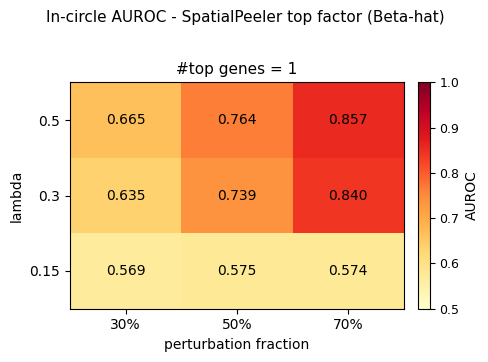

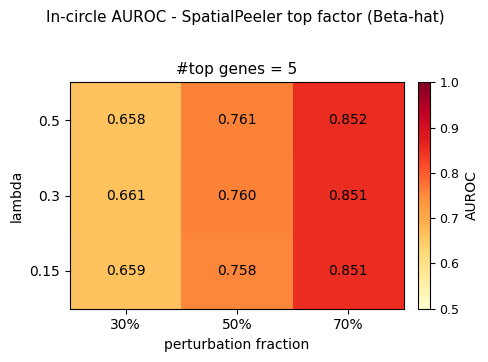

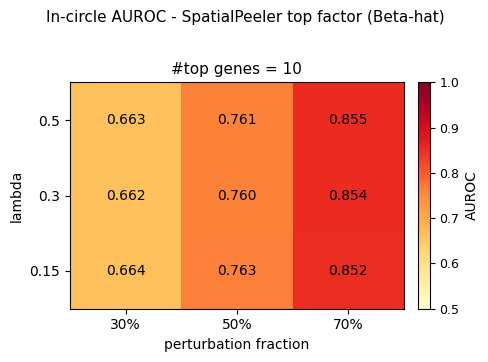

In [ ]:
vmin, vmax = 0.5, 1.0

for tg in TOP_GENES_LIST:
    sub = results_df[results_df['top_genes'] == tg]
    mat = sub.pivot(index='fixed_lam', columns='perturb_frac', values='top_auc')
    mat = mat.sort_index(ascending=False)

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ## set colorbar limits to same range for all plots from 0.5 to 1.0
    im = ax.imshow(mat.values, cmap='YlOrRd', vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels([f'{c:.0%}' for c in mat.columns], fontsize=10)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([str(r) for r in mat.index], fontsize=10)
    ax.set_xlabel('perturbation fraction', fontsize=10)
    ax.set_ylabel('lambda', fontsize=10)
    ax.set_title(f'#top genes = {tg}', fontsize=11)

    for r_i, row in enumerate(mat.values):
        for c_i, val in enumerate(row):
            ax.text(c_i, r_i, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, color='black')

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('AUROC', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    fig.suptitle('In-circle AUROC - SpatialPeeler top factor (Beta-hat)', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

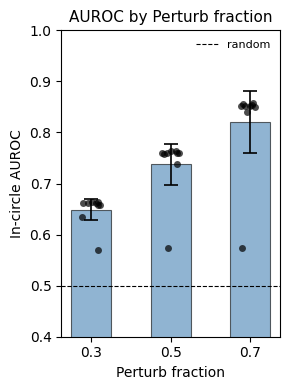

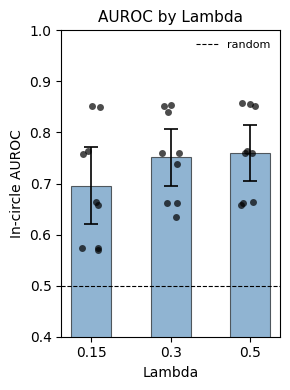

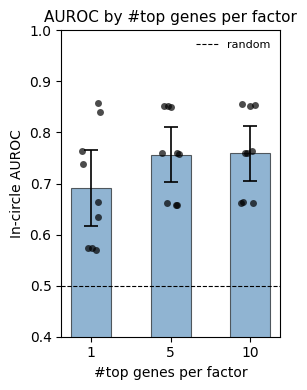

In [29]:
from scipy import stats

for col, label in [
    ('perturb_frac', 'Perturb fraction'),
    ('fixed_lam',    'Lambda'),
    ('top_genes',    '#top genes per factor'),
]:
    groups = sorted(results_df[col].unique())
    x_pos  = np.arange(len(groups))

    means, cis = [], []
    for grp in groups:
        vals = results_df.loc[results_df[col] == grp, 'top_auc'].values
        means.append(vals.mean())
        cis.append(stats.sem(vals) * 1.96)  # 95% CI half-width


    fig, ax = plt.subplots(figsize=(3, 4))
    ### add edge color as black with linewidth 0.8 to bars
    ax.bar(x_pos, means, color='steelblue', alpha=0.6, width=0.5, zorder=2, edgecolor='black', linewidth=0.8)
    ax.errorbar(x_pos, means, yerr=cis, fmt='none', color='black',
                capsize=5, capthick=1.2, linewidth=1.2, zorder=4)

    rng = np.random.default_rng(RAND_SEED)
    for xi, grp in zip(x_pos, groups):
        vals   = results_df.loc[results_df[col] == grp, 'top_auc'].values
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(xi + jitter, vals, color='black', s=25, zorder=3,
                   alpha=0.7, linewidths=0)

    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, label='random')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(g) for g in groups], fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('In-circle AUROC', fontsize=10)
    ax.set_title(f'AUROC by {label}', fontsize=11)
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.show()


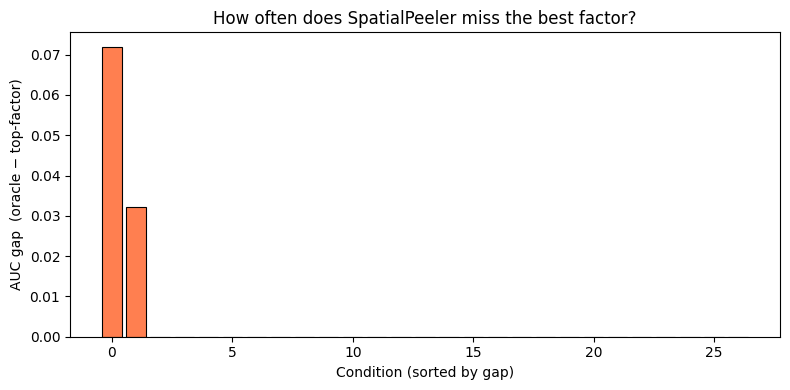

count    27.000
mean      0.004
std       0.015
min       0.000
25%       0.000
50%       0.000
75%       0.000
max       0.072
Name: auc_gap, dtype: float64
Mean gap:   0.004
Cases where top_auc == best_auc: 25 / 27


In [ ]:
# Gap: how much does SpatialPeeler lose vs the oracle?
results_df['auc_gap'] = results_df['best_auc'] - results_df['top_auc']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(results_df)), results_df.sort_values('auc_gap', ascending=False)['auc_gap'],
       color='coral', edgecolor='black', linewidth=0.8)
ax.set_xlabel('Condition (sorted by gap)')
ax.set_ylabel('AUC gap  (oracle − top-factor)')
ax.set_title('How often does SpatialPeeler miss the best factor?')
ax.axhline(0, color='black', linewidth=0.6)
plt.tight_layout()
plt.show()

results_df['auc_gap'] = results_df['best_auc'] - results_df['top_auc']

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(results_df['auc_gap'], bins=15, color='coral', edgecolor='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('AUC gap  (oracle − top-factor)', fontsize=10)
ax.set_ylabel('Number of conditions', fontsize=10)
ax.set_title('SpatialPeeler: gap to oracle best factor', fontsize=11)

print(results_df['auc_gap'].describe().round(3))
print(f'Cases where gap = 0: {(results_df["auc_gap"] < 1e-6).sum()} / {len(results_df)}')


print(results_df['auc_gap'].describe().round(3))

print(f'Mean gap:   {results_df["auc_gap"].mean():.3f}')
print(f'Cases where top_auc == best_auc: '
      f'{(results_df["auc_gap"] < 1e-6).sum()} / {len(results_df)}')

### 7. Per-factor AUC: low vs high for each parameter\n\nFor each of the 3 parameters, compare the two extreme values (low / high),averaging the other two parameters out. Each subplot shows the in-circle AUROC\nfor all 15 NMF factors; the dot marks the factor SpatialPeeler chose (highest β).